In [7]:
import numpy as np                       # numpy is udes for arrays, arithmetic operations, logarithmic spacing (logspace)
from scipy.integrate import solve_ivp    # matplotlib is udes for plots
import matplotlib.pyplot as plt          # solve_ivp is an ODE solver

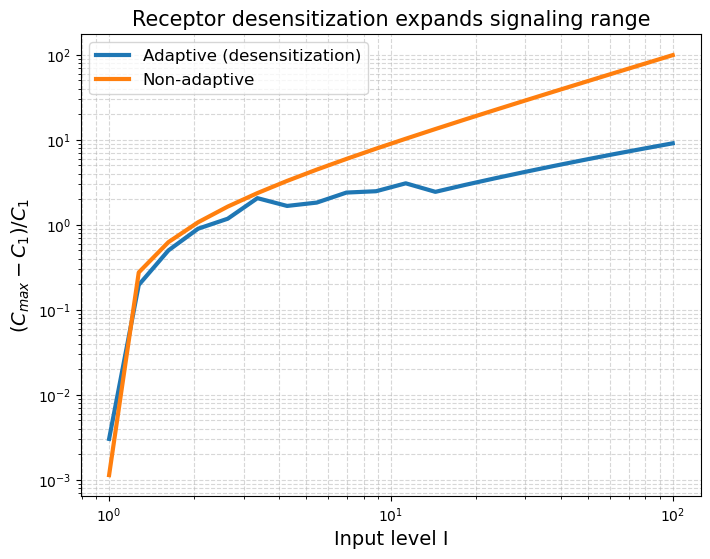

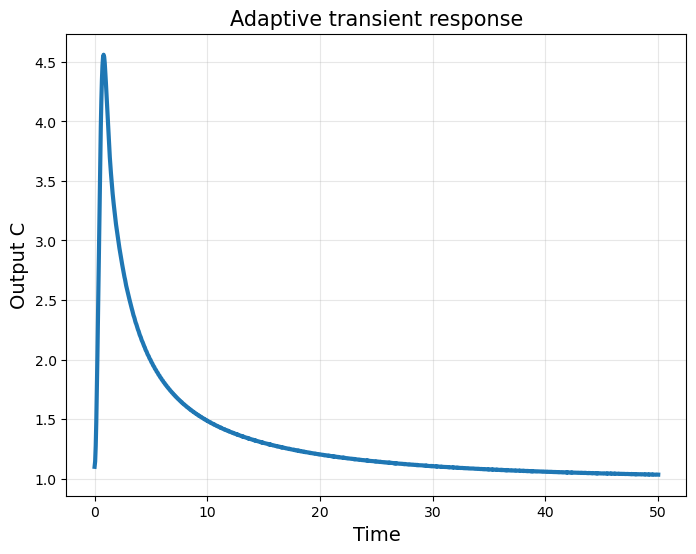

In [9]:
# ============================================================
# PARAMETERS
# ============================================================

# Common parameters  (kinetic constants)
kI = 1.0              # input activation rate :I→A
kFA = 1.0             # degradation / relaxation of A
kAC = 2.0             # activation of output: A→C

# Adaptive network   (feedback parameters)
kCB = 1.0            # C activates  B: C→B
kFB = 1.0            # basal degradation of B
kBC = 2.0            # B inhibits C: B⊣C

# Saturation constants  (Michaelis - Menten constants: check how easily the reaction saturates)
K1 = 0.01        # We need k1 and k2 small because we want: (1−B)≫K1 and B≫K2 so: (1−B)/((1-B)+K1)≈1 and
K2 = 0.01        # B/(B+K2)≈1. That generates integral feedback.

# ============================================================
# ADAPTIVE NETWORK (Integral negative feedback)
# ============================================================

def adaptive_network(t, y, I):        # With the adaptive network function we define the ODE system. Inputs: t (time), y (vector of the 
                                      # (biological) variables: A (input), B (desensitization / feedback), C (output).
    A, B, C = y

    # Input node
    dA = kI * I - kFA * A             # 1st term: Input activates A, 2nd term: A degrades

    # Integral feedback node (saturating reactions)
    dB = (                                   # 1st term/ Activation term: C activates B. Saturation means B do not increases unlimitedly.
        kCB * C * (1 - B) / ((1 - B) + K1)   # 2nd term/ Deactivation term: Michaelis - Menten degradation.
        - kFB * B / (B + K2)
    )

    # Output node
    dC = kAC * A - kBC * B * C               # 1st term: A activates output and 2nd term: B suppresses/desensitizes output.

    return [dA, dB, dC]                      # Return derivatives: solver needs solver χρειάζεται: [dA/dt, dB/dt, dC/dt]

# ============================================================
# NON-ADAPTIVE NETWORK
# ============================================================

def nonadaptive_network(t, y, I):            # There is no feedback here. I→A→C without adaptation.

    A, C = y

    dA = kI * I - kFA * A
    dC = kAC * A - kFA * C

    return [dA, dC]

# ============================================================
# FUNCTION TO COMPUTE RESPONSE AMPLITUDE
# ============================================================

def compute_response_amplitude(model, I_values, adaptive=True):       # This function runs simulations and computes amplitudes.

    amplitudes = []

    for I2 in I_values:                            # Loop over input levels. We are testing a lot of different inputs.

        I1 = 1.0  # baseline input                 # Baseline input. Initial steady-state.

        # ----------------------------------------------------
        # Steady state before stimulation
        # ----------------------------------------------------

        if adaptive:

            y0 = [0.1, 0.1, 0.1]

            sol_pre = solve_ivp(                   # Pre-stimulation steady-state. We are solving ODE for a long time interval so, 
                lambda t, y: model(t, y, I1),      # the system reaches steady-state.
                [0, 100],                          # We are using "lambda" because we are giving fixed input I1 (lambda "locks" I1) . 
                y0,                                # lambda t, y: model(t, y, I1) is equal to def wrapped_function(t, y):
                t_eval=np.linspace(0, 100, 1000)   # def wrapped_function(t, y):                                   
            )                                      #     return model(t, y, I1)
                                                   # In general, 
                                                   # f = lambda x: x**2     
                                                   # is equal to      
                                                   # def f(x):
                                                   #     return x**2
            
            ss = sol_pre.y[:, -1]         # Extract steady-state (sol_pre: all the solutions, [:, -1]: latest time-point, ie. (A*, B*, C*).

            # ------------------------------------------------
            # Step increase
            # ------------------------------------------------

            sol_post = solve_ivp(                 # Apply stimulus step. Now we switch: I1→I2 and observe the response.
                lambda t, y: model(t, y, I2),
                [0, 100],
                ss,
                t_eval=np.linspace(0, 100, 2000)
            )

            C = sol_post.y[2]             # We take the output.

        else:

            y0 = [0.1, 0.1]

            sol_pre = solve_ivp(
                lambda t, y: model(t, y, I1),
                [0, 100],
                y0,
                t_eval=np.linspace(0, 100, 1000)
            )

            ss = sol_pre.y[:, -1]

            sol_post = solve_ivp(
                lambda t, y: model(t, y, I2),
                [0, 100],
                ss,
                t_eval=np.linspace(0, 100, 2000)
            )

            C = sol_post.y[1]

        # ----------------------------------------------------
        # Response amplitude
        # ----------------------------------------------------

        C1 = C[0]                  # C1: steady-state before stimulation. 
        Cmax = np.max(C)           # Cmax: peak response.

        amplitude = (Cmax - C1) / C1     # We compute the response amplitude.

        amplitudes.append(amplitude)

    return amplitudes

# ============================================================
# INPUT RANGE
# ============================================================

I_values = np.logspace(0, 2, 20)      # Logarithmic spacing: 10^0→10^2, ie. 1→100.

# ============================================================
# COMPUTE AMPLITUDES
# ============================================================

adaptive_amp = compute_response_amplitude(
    adaptive_network,
    I_values,
    adaptive=True
)

nonadaptive_amp = compute_response_amplitude(
    nonadaptive_network,
    I_values,
    adaptive=False
)

# ============================================================
# PLOT: SIGNALING RANGE
# ============================================================

plt.figure(figsize=(8,6))

plt.loglog(
    I_values,
    adaptive_amp,
    linewidth=3,
    label='Adaptive (desensitization)'
)

plt.loglog(
    I_values,
    nonadaptive_amp,
    linewidth=3,
    label='Non-adaptive'
)

plt.xlabel('Input level I', fontsize=14)
plt.ylabel(r'$(C_{max}-C_1)/C_1$', fontsize=14)

plt.title('Receptor desensitization expands signaling range',
          fontsize=15)

plt.legend(fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

# ============================================================
# EXAMPLE TIME TRACE
# ============================================================

# Example input step
I_before = 1.0
I_after = 20.0

# Steady state before step
sol_pre = solve_ivp(
    lambda t, y: adaptive_network(t, y, I_before),
    [0, 100],
    [0.1, 0.1, 0.1],
    t_eval=np.linspace(0, 100, 1000)
)

ss = sol_pre.y[:, -1]

# Response after step
sol_post = solve_ivp(
    lambda t, y: adaptive_network(t, y, I_after),
    [0, 50],
    ss,
    t_eval=np.linspace(0, 50, 1000)
)

t = sol_post.t
A, B, C = sol_post.y

# Plot time trace
plt.figure(figsize=(8,6))

plt.plot(t, C, linewidth=3)

plt.xlabel('Time', fontsize=14)
plt.ylabel('Output C', fontsize=14)

plt.title('Adaptive transient response', fontsize=15)

plt.grid(True, alpha=0.3)

plt.show()